# Retina layer sweep

In [2]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
sys.path.append('../../deconversation')
from pseudobulk import *
from preprocessing import *
from embeddings_1 import *
from deconvolution import *
from visualization import *

geneformer successfully imported.
cell2sentence is not installed. Skipping related functions.
cellhermes is not installed. Skipping related functions.
scGPT is not installed. Skipping related functions.
scVI successfully imported.


In [6]:
dataset_name = 'retina'
reference_path = '/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/retina_ref1test2/subref_signature_matrix_id.csv'
bulk_path = '/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/retina_ref1test2/bulk2_id.csv'
ground_truth_path = '/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/retina_ref1test2/ground_truth_batch2.csv'

# Sig mat
signature_df = pd.read_csv(reference_path, index_col=0)
signature_df = signature_df.T

# bulk data
bulk_df = pd.read_csv(bulk_path, index_col=0)
bulk_df = bulk_df.T
bulk_df = bulk_df.loc[bulk_df.index.dropna()]

# Ground truth
ground_truth = pd.read_csv(ground_truth_path, index_col=0)
ground_truth = ground_truth.T

In [13]:
signature_df.head()

author_cell_type,AC,BC,Cone,HC,NN,Rod
ENSG00000243485,0.000025,0.007665,0.011325,0.000035,0.00002,0.00548
ENSG00000237613,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
ENSG00000186092,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
ENSG00000239945,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
ENSG00000239906,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000


In [11]:
def harmonize_columns(df):
    df = df.copy()
    if 'RGC' in df.columns and 'MG' in df.columns:
        df['NN'] = df['RGC'] + df['MG']
        df = df.drop(columns=['RGC', 'MG'])
    return df

In [14]:
ground_truth = harmonize_columns(ground_truth)

### Zero Shot

In [18]:
layer_results = {}
metric_rows = []
celltype_rows = []
for layer in range(1, 19):
    print(f'=== layer {layer} ===', flush=True)
    sig_mat_gf_embed = extract_embs(
        bulk_df=signature_df.T,
        mode='geneformer',
        temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/',
        model_path='ctheodoris/Geneformer',
        delete_temp_files=True,
        layer_to_quant=layer,
    )
    gf_embed = extract_embs(
        bulk_df=bulk_df,
        mode='geneformer',
        temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/',
        model_path='ctheodoris/Geneformer',
        delete_temp_files=True,
        layer_to_quant=layer,
    )
    results = run_all_deconv(bulk_df=gf_embed.T, signature_df=sig_mat_gf_embed.T)
    results = {solver: harmonize_columns(df) for solver, df in results.items()}
    layer_results[layer] = results
    for solver, df in results.items():
        samples = df.index.intersection(ground_truth.index)
        celltypes = df.columns.intersection(ground_truth.columns)
        P = df.loc[samples, celltypes].astype(float)
        T = ground_truth.loc[samples, celltypes].astype(float)
        p = P.values.ravel()
        t = T.values.ravel()
        ok = np.isfinite(p) & np.isfinite(t)
        for ct in celltypes:
            a = P[ct].values
            b = T[ct].values
            m = np.isfinite(a) & np.isfinite(b)
            if m.sum() > 1 and np.std(a[m]) > 0 and np.std(b[m]) > 0:
                r_ct = np.corrcoef(a[m], b[m])[0, 1]
            else:
                r_ct = np.nan
            celltype_rows.append({'layer': layer, 'solver': solver, 'celltype': ct, 'correlation': r_ct, 'rmse': np.sqrt(np.mean((a[m] - b[m]) ** 2)) if m.sum() else np.nan})
        ct_sub = [r for r in celltype_rows if r['layer'] == layer and r['solver'] == solver]
        corrs = np.array([r['correlation'] for r in ct_sub], dtype=float)
        mean_corr = np.mean(np.nan_to_num(corrs, nan=0.0))
        mean_rmse = np.nanmean([r['rmse'] for r in ct_sub])
        metric_rows.append({'layer': layer, 'solver': solver, 'correlation': np.corrcoef(p[ok], t[ok])[0, 1], 'rmse': np.sqrt(np.mean((p[ok] - t[ok]) ** 2)), 'meanCorrelation': mean_corr, 'meanRMSE': mean_rmse})

metrics_df = pd.DataFrame(metric_rows)
celltype_df = pd.DataFrame(celltype_rows)

metrics_df.to_csv('../../results/layer_sweep_metrics_zeroshot_retina.csv', index=False)

=== layer 1 ===
Pseudobulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 35.10it/s]
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:787: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a va

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.
Loading Geneformer model...


CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


Loading tokenized dataset...
Extracting Geneformer embeddings...


...

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.
Loading Geneformer model...


CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/1 [00:00<?, ?it/s]

Running solver: nnls
Running solver: nnls_mod
Running solver: dwls
Running solver: simplex
Running solver: ridge_simplex
Running solver: dwls_simplex
Running solver: ridge
Running solver: elasticnet
Running solver: nusvr


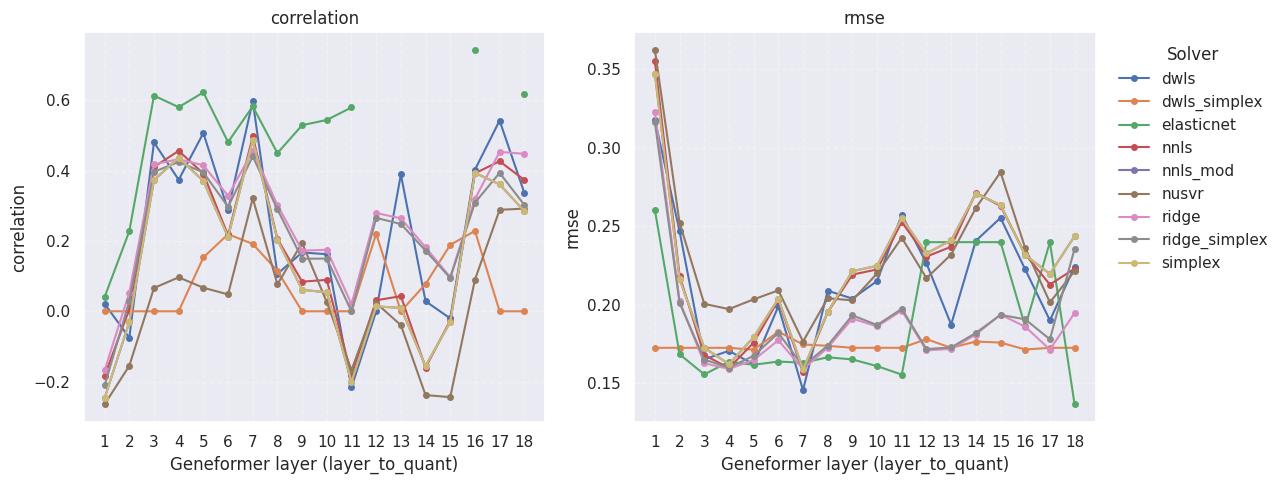

     layer         solver  correlation      rmse  meanCorrelation  meanRMSE
56       7           dwls     0.597129  0.145480         0.248801  0.138294
140     16   dwls_simplex     0.228599  0.171398         0.022428  0.149940
142     16     elasticnet     0.742777  0.186092        -0.145407  0.164641
54       7           nnls     0.497132  0.157248         0.277342  0.145065
55       7       nnls_mod     0.486315  0.158677         0.277997  0.146059
62       7          nusvr     0.321273  0.176498         0.253121  0.159819
60       7          ridge     0.456067  0.158813         0.255279  0.144340
58       7  ridge_simplex     0.440681  0.160699         0.274251  0.145997
57       7        simplex     0.486313  0.158677         0.279199  0.146060


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['correlation', 'rmse']):
    for solver, sub in metrics_df.groupby('solver'):
        sub = sub.sort_values('layer')
        ax.plot(sub['layer'], sub[metric], marker='o', markersize=4, label=solver)
    ax.set_xlabel('Geneformer layer (layer_to_quant)')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticks(range(1, 19))
    ax.grid(alpha=0.3, linestyle='--')
axes[1].legend(title='Solver', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig('../../results/layer_sweep_zeroshot_retina.png', dpi=300, bbox_inches='tight')
plt.show()
print(metrics_df.loc[metrics_df.groupby('solver')['correlation'].idxmax()])

### Fine-tuned

In [22]:
layer_results = {}
metric_rows = []
celltype_rows = []
for layer in range(1, 19):
    print(f'=== layer {layer} ===', flush=True)
    sig_mat_gf_embed = extract_embs(
        bulk_df=signature_df.T,
        mode='geneformer',
        temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/',
        model_path='/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/retina_ref1test2/geneformer/complete/finetuned316m/260301_geneformer_cellClassifier_cell_annot_subset/ksplit1/',
        delete_temp_files=True,
        layer_to_quant=layer,
    )
    gf_embed = extract_embs(
        bulk_df=bulk_df,
        mode='geneformer',
        temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/',
        model_path='/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/retina_ref1test2/geneformer/complete/finetuned316m/260301_geneformer_cellClassifier_cell_annot_subset/ksplit1/',
        delete_temp_files=True,
        layer_to_quant=layer,
    )
    results = run_all_deconv(bulk_df=gf_embed.T, signature_df=sig_mat_gf_embed.T)
    results = {solver: harmonize_columns(df) for solver, df in results.items()}
    layer_results[layer] = results
    for solver, df in results.items():
        samples = df.index.intersection(ground_truth.index)
        celltypes = df.columns.intersection(ground_truth.columns)
        P = df.loc[samples, celltypes].astype(float)
        T = ground_truth.loc[samples, celltypes].astype(float)
        p = P.values.ravel()
        t = T.values.ravel()
        ok = np.isfinite(p) & np.isfinite(t)
        for ct in celltypes:
            a = P[ct].values
            b = T[ct].values
            m = np.isfinite(a) & np.isfinite(b)
            if m.sum() > 1 and np.std(a[m]) > 0 and np.std(b[m]) > 0:
                r_ct = np.corrcoef(a[m], b[m])[0, 1]
            else:
                r_ct = np.nan
            celltype_rows.append({'layer': layer, 'solver': solver, 'celltype': ct, 'correlation': r_ct, 'rmse': np.sqrt(np.mean((a[m] - b[m]) ** 2)) if m.sum() else np.nan})
        ct_sub = [r for r in celltype_rows if r['layer'] == layer and r['solver'] == solver]
        corrs = np.array([r['correlation'] for r in ct_sub], dtype=float)
        mean_corr = np.mean(np.nan_to_num(corrs, nan=0.0))
        mean_rmse = np.nanmean([r['rmse'] for r in ct_sub])
        metric_rows.append({'layer': layer, 'solver': solver, 'correlation': np.corrcoef(p[ok], t[ok])[0, 1], 'rmse': np.sqrt(np.mean((p[ok] - t[ok]) ** 2)), 'meanCorrelation': mean_corr, 'meanRMSE': mean_rmse})

metrics_df = pd.DataFrame(metric_rows)
celltype_df = pd.DataFrame(celltype_rows)

metrics_df.to_csv('../../results/layer_sweep_metrics_finetuned_retina.csv', index=False)

=== layer 1 ===
Pseudobulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 35.97it/s]
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:787: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a va

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.
Loading Geneformer model...


Some weights of BertForMaskedLM were not initialized from the model checkpoint at /gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/retina_ref1test2/geneformer/complete/finetuned316m/260301_geneformer_cellClassifier_cell_annot_subset/ksplit1/ and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


Loading tokenized dataset...
Extracting Geneformer embeddings...


...

Loading Geneformer model...


CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/1 [00:00<?, ?it/s]

Running solver: nnls
Running solver: nnls_mod
Running solver: dwls
Running solver: simplex
Running solver: ridge_simplex
Running solver: dwls_simplex
Running solver: ridge
Running solver: elasticnet
Running solver: nusvr


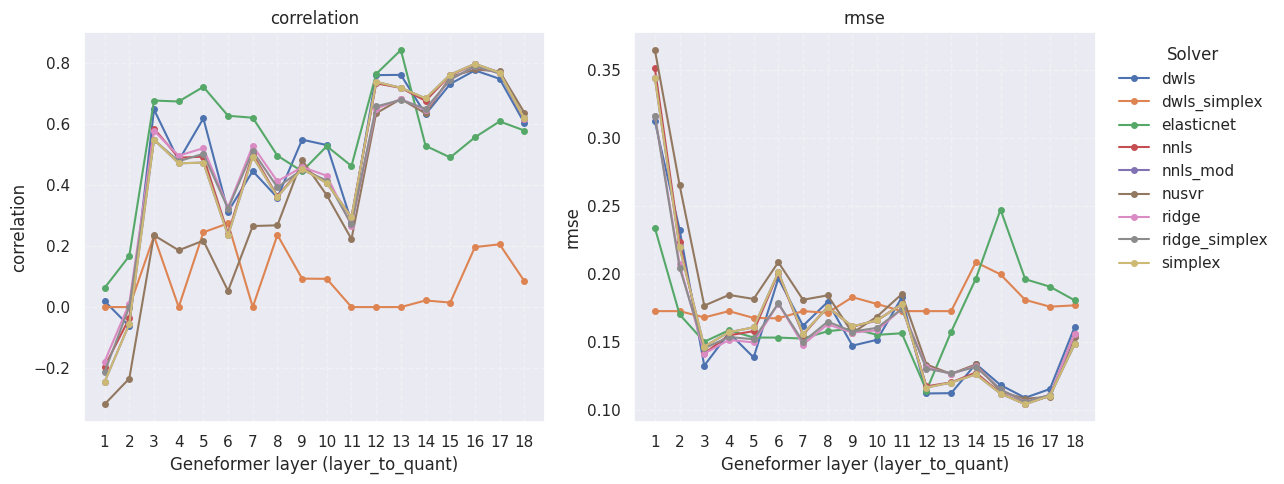

     layer         solver  correlation      rmse  meanCorrelation  meanRMSE
137     16           dwls     0.776452  0.108748         0.366181  0.097923
50       6   dwls_simplex     0.274638  0.167186         0.095582  0.142676
115     13     elasticnet     0.843080  0.157244         0.195240  0.134199
135     16           nnls     0.796148  0.104368         0.365035  0.092960
136     16       nnls_mod     0.797923  0.103965         0.366408  0.092642
143     16          nusvr     0.779501  0.108038         0.337149  0.096175
141     16          ridge     0.789954  0.105847         0.358990  0.093258
139     16  ridge_simplex     0.790375  0.105693         0.358678  0.093212
138     16        simplex     0.797923  0.103965         0.366408  0.092642


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['correlation', 'rmse']):
    for solver, sub in metrics_df.groupby('solver'):
        sub = sub.sort_values('layer')
        ax.plot(sub['layer'], sub[metric], marker='o', markersize=4, label=solver)
    ax.set_xlabel('Geneformer layer (layer_to_quant)')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticks(range(1, 19))
    ax.grid(alpha=0.3, linestyle='--')
axes[1].legend(title='Solver', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig('../../results/layer_sweep_finetuned_retina.png', dpi=300, bbox_inches='tight')
plt.show()
print(metrics_df.loc[metrics_df.groupby('solver')['correlation'].idxmax()])